# BERT, Retrieval Augmented Generation (RAG) y DenseNet

## Equipo 8:

* Andres Camilo Torres Cajamarca (antorresca@unal.edu.co)
* Adrian Ramirez Gonzalez (adramirez@unal.edu.co)
* Andres Felipe Poveda Bellon (anpovedab@unal.edu.co)
* Jorge Aurelio Morales Manrique (jomorales@unal.edu.co)
* Miguel Angel Pinzon Garcia (mipinzong@unal.edu.co)

# **BERT**

BERT (Bidirectional Encoder Representations from Transformers) es un modelo de representacion del lenguaje cuya principal novedad es que implemento el aprovechamiento del contexto a izquierda y derecha del token.

## **Transformadores**

Los transformadores son un tipo de red neuronal que emplea mecanismos de autoatencion, los cuales permiten determinar que partes de una secuencia son mas importantes. Esta arquitectura se ha vuelto muy util en la construccion de modelos de lenguaje de gran escala como GPT o BERT, los cuales implementan variantes de esta arquitectura.

### **Arquitectura general del transformador**

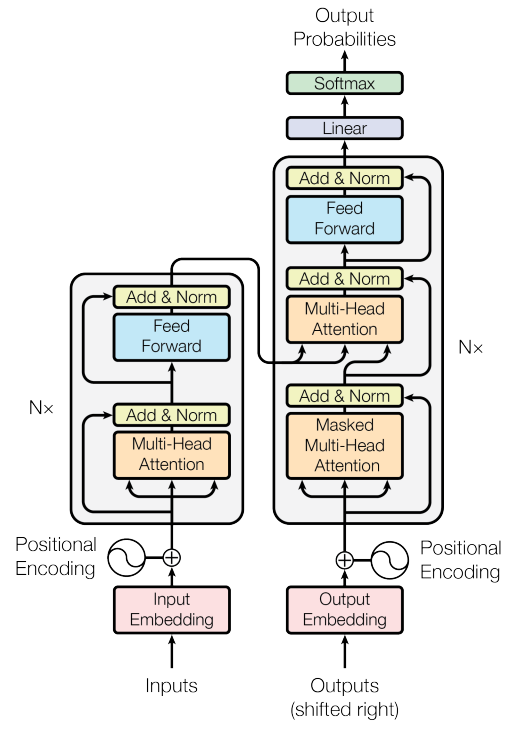

El transformador cuenta con dos partes:
1. **Codificador (Caja gris de la izquierda):** Cuenta con una capa relacionada con el mecanismo de auto atencion multi-cabeza, una capa de feed forward y capas de normalizacion. El codificador se compondria de 6 capas apiladas iguales a esta.
2. **Decodificador (Caja gris de la derecha):** Es igual al codificador, pero tiene una capa adicional del mecanismo de auto atencion y tambien una capa adicional de normalizacion. Esta capa adicional del mecanismo de auto atencion usa la salida del codificador como parte de su entrada. Por otro lado, la entrada de el decodificador seria la salida desplazada hacia la derecha y, de forma similar al codificador, el decodificador tambien se compondria de 6 capas apiladas iguales a esta. Adicionalmente, la primera capa de auto atencion del decodificador se encuentra modificada para evitar que se tome en cuenta los valores posteriores de la secuencia.

### **Unidireccionalidad y Bidireccionalidad**

Los creadores de BERT identificaron que las arquitecturas unidireccionales donde unicamente se tenia en cuenta los tokens previos al token que se queria analizar (como GPT) podian afectar la realizacion de procesos de fine-tuning en algunos contextos, debido a que no tenian en cuenta el contexto que ofrecian los tokens posteriores al token que se queria analizar. Por esta razon se creo BERT con el fin de ofrecer un modelo bidireccional que fuera capaz de tener en cuenta todo el contexto.

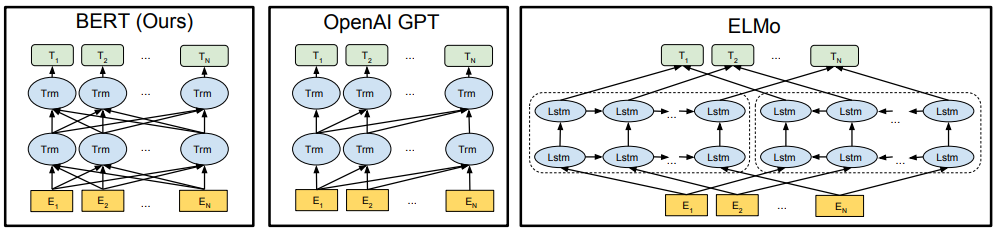

### **Pre entrenamiento de BERT**

Para lograr crear un modelo del lenguaje bidireccional, el pre entrenamiento del modelo se dividio en dos partes:
1. Implementacion de Masked Language Model (MLM) la cual busca ocultar algunos tokens para posteriormente intentar predecir el token que deberia ir en esa posicion. Este enfoque permite tener en cuenta todo el contexto para intentar predecir el token enmascarado.
2. Implementacion de prediccion de la siguiente oracion con el objetivo de mejorar la capacidad del modelo para entender la relacion entre oraciones.

#### **Datasets usados en el pre entrenamiento**
* BooksCorpus (800 Millones de palabras)
* Wikipedia en Ingles (2500 Millones de palabras)

### **Versiones de BERT creadas**

#### **BERT Base**
* Cantidad de parametros: 110 Millones
#### **Bert Large**
* Cantidad de parametros: 340 Millones

# Ejemplo de MLM (Masked Language Model)
Ejemplo creado a partir de la documentacion de BERT en HuggingFace: https://huggingface.co/google-bert/bert-base-uncased

In [ ]:
from transformers import pipeline
mlm = pipeline('fill-mask', model='bert-base-uncased')

mask_sentences = [
  "I'm sad because I lost my [MASK].",
  "My favorite sport is [MASK].",
  "I think [MASK] is a good country."
]

print("\n\n\n")

for sentence in mask_sentences:
  print(f"Oracion enmascarada: {sentence}\n")
  outputs = mlm(sentence)
  for output in outputs[:3]:
    print(f"Prediccion: {output["token_str"]}")
    print(f"Score: {output["score"]}")
    print(f"Oracion completa: {output["sequence"]}")

  print("\n------------------------------------------------\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]





Oracion enmascarada: I'm sad because I lost my [MASK].

Prediccion: job
Score: 0.10973940044641495
Oracion completa: i ' m sad because i lost my job.
Prediccion: parents
Score: 0.1056770533323288
Oracion completa: i ' m sad because i lost my parents.
Prediccion: mother
Score: 0.09047187864780426
Oracion completa: i ' m sad because i lost my mother.

------------------------------------------------

Oracion enmascarada: My favorite sport is [MASK].

Prediccion: football
Score: 0.25891613960266113
Oracion completa: my favorite sport is football.
Prediccion: basketball
Score: 0.19561077654361725
Oracion completa: my favorite sport is basketball.
Prediccion: swimming
Score: 0.08468811213970184
Oracion completa: my favorite sport is swimming.

------------------------------------------------

Oracion enmascarada: I think [MASK] is a good country.

Prediccion: this
Score: 0.23708650469779968
Oracion completa: i think this is a good country.
Prediccion: it
Score: 0.21383079886436462
Oraci

### Ejemplo: Uso de BERT para responder preguntas

Uno de los usos que se le puede dar a BERT es para dar respuesta a preguntas a partir de un contexto. En este caso, como contexto se le dara a BERT una pieza de texto proveniente del documento del Proyecto Educativo de Programa (PEP) del pregrado de Ingenieria de sistemas y computacion publicado por la Universidad Nacional de Colombia. Esta pieza de texto habla sobre los inicios de este pregrado. El texto sera traducido a ingles para facilitar el analisis que debe realizar el modelo.  

En este ejemplo se usara el modelo **distilbert-base-cased-distilled-squad**. Este es un modelo de BERT mas ligero el cual paso por un proceso de fine-tuning usando el dataset SQuAD v1.1 (un dataset de preguntas y respuestas). Link del modelo: https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad

In [ ]:
from transformers import pipeline

BERT = pipeline('question-answering', model="distilbert-base-cased-distilled-squad")

context = """
The origins of the Program date back to the mid-1960s when the "Specialization Program in Systems Engineering" was
created in 1967 as part of the Faculty's "Specialization Program for Graduates" initiative, which led to Master's
degrees in various specializations. These programs were carried out with the support of the National Planning
Department and UNESCO. The Specialization Program in Systems Engineering awarded the title of Master in Systems
or Master in Systems Engineering and has evolved into the current Master's in Systems and Computer Engineering.
The Specialization Program for Graduates began in the Faculty of Engineering in 1966, during the rectorship of
Guillermo Rueda Montaña and the deanship of Diego López Arango, with specializations in Structures, Transportation, and Sanitation.
Also during the sixties, the University created the Preparatory Computing Office which in 1964 became
the Computing Center attached to the General Vice-Rector's Office and acquired an IBM 1620 model I computer.
"""

questions = [
    "What year did the Graduate Specialization Program begin?",
    "What machine was acquired in 1964?",
    "What were the first specialization areas when the Graduate Specialization Program began?",
    "Who was the rector in 1966?"
]

for question in questions:
  print(f"Pregunta: {question}")
  print(f"Respuesta: {BERT(question=question, context=context)}")

print("\n////////////////////////////////////////////////////////////////////////////////\n")

q = input("Haz una pregunta al modelo (en ingles): ")
print(f"Respuesta: {BERT(question=q, context=context)}")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Pregunta: What year did the Graduate Specialization Program begin?
Respuesta: {'score': 0.9677140712738037, 'start': 649, 'end': 653, 'answer': '1966'}
Pregunta: What machine was acquired in 1964?
Respuesta: {'score': 0.5692124962806702, 'start': 999, 'end': 1024, 'answer': 'IBM 1620 model I computer'}
Pregunta: What were the first specialization areas when the Graduate Specialization Program began?
Respuesta: {'score': 0.9453935458150227, 'start': 769, 'end': 811, 'answer': 'Structures, Transportation, and Sanitation'}
Pregunta: Who was the rector in 1966?
Respuesta: {'score': 0.9914795495369617, 'start': 681, 'end': 704, 'answer': 'Guillermo Rueda Montaña'}

////////////////////////////////////////////////////////////////////////////////

Haz una pregunta al modelo (en ingles): Who was the dean in 1966?
Respuesta: {'score': 0.9884147570628556, 'start': 725, 'end': 743, 'answer': 'Diego López Arango'}


## RAG

<div align='justify'>

### Contexto y Motivación

Los grandes modelos de lenguaje (LLMs) como GPT o BERT aprenden un vasto conocimiento durante el entrenamiento, pero este conocimiento queda **congelado** en los pesos del modelo. Esto genera dos problemas fundamentales:

- **Conocimiento desactualizado**: el modelo no sabe nada de lo que ocurrió después de su fecha de corte de entrenamiento.
- **Alucinaciones**: ante preguntas sobre información específica o privada que no vio en entrenamiento, el modelo puede inventar respuestas plausibles pero incorrectas.

**RAG** (*Retrieval Augmented Generation*), propuesto por Lewis et al. (2020), resuelve esto acoplando el LLM a una **base de conocimiento externa y dinámica**. En lugar de responder solo desde sus pesos, el modelo primero *recupera* fragmentos relevantes del corpus externo y luego los usa como contexto para *generar* la respuesta.

</div>

<div align='center'>
<img src='https://upload.wikimedia.org/wikipedia/commons/1/14/RAG_diagram.svg' width=600px>
<br><em>Figura: Diagrama general del pipeline RAG — Recuperación + Generación augmentada</em>
</div>

<div align='justify'>

</div>

<div align='justify'>

### LLM estándar vs. RAG

La diferencia clave entre ambos enfoques está en cómo el modelo accede al conocimiento al momento de inferencia:

</div>

<div align='center'>
<table style="border-collapse:collapse; font-size:0.92em; margin:10px auto;">
<thead><tr style="background:#2166AC; color:white;">
  <th style="padding:7px 18px;">Aspecto</th>
  <th style="padding:7px 18px;">LLM estándar</th>
  <th style="padding:7px 18px;">RAG</th>
</tr></thead>
<tbody>
<tr><td style="padding:5px 18px;">Fuente del conocimiento</td><td align="center">Pesos del modelo (estático)</td><td align="center"><b>Base de datos externa (dinámico)</b></td></tr>
<tr><td style="padding:5px 18px;">Actualización del conocimiento</td><td align="center">Requiere re-entrenamiento</td><td align="center"><b>Actualizar el corpus es suficiente</b></td></tr>
<tr><td style="padding:5px 18px;">Alucinaciones</td><td align="center">Frecuentes en temas específicos</td><td align="center"><b>Reducidas (respuestas ancladas)</b></td></tr>
<tr><td style="padding:5px 18px;">Trazabilidad</td><td align="center">No</td><td align="center"><b>Sí (fuentes citables)</b></td></tr>
<tr><td style="padding:5px 18px;">Costo de actualización</td><td align="center">Alto (reentrenamiento)</td><td align="center"><b>Bajo (solo re-indexar)</b></td></tr>
<tr><td style="padding:5px 18px;">Conocimiento privado/dominio</td><td align="center">Limitado</td><td align="center"><b>Nativo</b></td></tr>
</tbody>
</table>
</div>

<div align='justify'>

### Arquitectura de RAG

Un sistema RAG se compone de dos grandes fases: **indexación** del corpus y **pipeline de consulta**.

---

#### Fase 1: Indexación (offline)

Antes de responder consultas, el corpus de documentos se preprocesa y almacena en un *vector store*:

**1. Segmentación (*chunking*)**: el documento $D$ se divide en fragmentos de tamaño fijo o semántico:

$$D \;\xrightarrow{\text{split}}\; \{c_1, c_2, \ldots, c_n\}$$

**2. Generación de embeddings**: cada chunk $c_i$ se convierte en un vector denso mediante un modelo de embeddings $\phi$:

$$\mathbf{v}_i = \phi(c_i) \in \mathbb{R}^d$$

**3. Almacenamiento en un vector store**: los pares $(c_i, \mathbf{v}_i)$ se guardan en una base de datos vectorial (FAISS, Chroma, Pinecone, etc.) optimizada para búsqueda por similitud.

---

#### Fase 2: Pipeline de consulta (online)

Cuando llega una consulta del usuario, el sistema ejecuta tres pasos:

**1. Codificación de la consulta**: la pregunta $q$ se convierte en un embedding con el mismo modelo $\phi$:

$$\mathbf{q} = \phi(q) \in \mathbb{R}^d$$

**2. Recuperación (*retrieval*)**: se buscan los $k$ fragmentos más similares a $\mathbf{q}$ en el vector store usando similitud coseno:

$$\text{sim}(\mathbf{q}, \mathbf{v}_i) = \frac{\mathbf{q} \cdot \mathbf{v}_i}{\|\mathbf{q}\| \|\mathbf{v}_i\|}, \qquad \mathcal{R} = \underset{i}{\text{top-}k}\;\text{sim}(\mathbf{q}, \mathbf{v}_i)$$

**3. Generación aumentada**: los chunks recuperados $\mathcal{R} = \{c_{r_1}, \ldots, c_{r_k}\}$ se concatenan con la pregunta y se pasan al LLM como contexto:

$$\text{respuesta} = \text{LLM}\!\left(q \;\|\; c_{r_1} \;\|\; \cdots \;\|\; c_{r_k}\right)$$

donde $\|$ denota concatenación en el prompt.

</div>

<div align='justify'>

### Componentes clave

#### 1. Modelo de embeddings

Transforma texto en vectores densos capturando significado semántico. Modelos populares: `sentence-transformers/all-MiniLM-L6-v2`, `text-embedding-ada-002` (OpenAI), `intfloat/e5-large`.

#### 2. Vector Store

Base de datos especializada en búsqueda por similitud a alta velocidad. Utiliza índices como **HNSW** (*Hierarchical Navigable Small World*) que permiten búsquedas aproximadas en $\mathcal{O}(\log n)$ en lugar de $\mathcal{O}(n)$.

#### 3. Estrategia de chunking

La forma en que se divide el documento impacta directamente la calidad de la recuperación:

</div>

<div align='center'>
<table style="border-collapse:collapse; font-size:0.92em; margin:10px auto;">
<thead><tr style="background:#2166AC; color:white;">
  <th style="padding:7px 16px;">Estrategia</th>
  <th style="padding:7px 16px;">Descripción</th>
  <th style="padding:7px 16px;">Ventaja</th>
</tr></thead>
<tbody>
<tr><td style="padding:5px 16px;">Tamaño fijo</td><td align="center">N tokens por chunk</td><td align="center">Simple, rápido</td></tr>
<tr><td style="padding:5px 16px;">Por oración/párrafo</td><td align="center">Límites naturales del texto</td><td align="center">Preserva coherencia</td></tr>
<tr><td style="padding:5px 16px;"><b>Semántico</b></td><td align="center">Agrupa oraciones similares</td><td align="center"><b>Mejor calidad semántica</b></td></tr>
<tr><td style="padding:5px 16px;">Jerárquico (T-RAG)</td><td align="center">Árbol de resúmenes recursivos</td><td align="center">Razonamiento multi-hop</td></tr>
</tbody>
</table>
</div>

<div align='justify'>

#### 4. Generador (LLM)

Produce la respuesta final condicionada al contexto recuperado. El diseño del **prompt** es crítico: debe indicarle al LLM que base su respuesta *exclusivamente* en el contexto provisto para minimizar alucinaciones.

---

### Ventajas y Limitaciones

**Ventajas:**
- Incorpora conocimiento actualizado o privado sin reentrenar el modelo.
- Las respuestas son trazables: se puede citar el fragmento fuente.
- Reduce significativamente las alucinaciones en dominios específicos.
- Modular: se puede cambiar el LLM o el corpus de forma independiente.

**Limitaciones:**
- La calidad depende fuertemente del recuperador: si los chunks no son relevantes, el LLM no puede generar una buena respuesta (*garbage in, garbage out*).
- Preguntas que requieren integrar información de múltiples partes del corpus (razonamiento multi-hop) son difíciles para RAG plano → motiva variantes como T-RAG.
- La latencia aumenta por el paso de recuperación adicional.
- Documentos con información contradictoria pueden confundir al generador.

</div>

<div align='justify'>

### Variantes de RAG

Desde el RAG original (Lewis et al., 2020), han surgido múltiples extensiones:

</div>

<div align='center'>
<table style="border-collapse:collapse; font-size:0.92em; margin:10px auto;">
<thead><tr style="background:#2166AC; color:white;">
  <th style="padding:7px 16px;">Variante</th>
  <th style="padding:7px 16px;">Novedad principal</th>
</tr></thead>
<tbody>
<tr><td style="padding:5px 16px;">RAG estándar</td><td style="padding:5px 16px;">Recuperación plana de chunks + generación</td></tr>
<tr><td style="padding:5px 16px;">HyDE</td><td style="padding:5px 16px;">Genera un documento hipotético para mejorar el embedding de la consulta</td></tr>
<tr><td style="padding:5px 16px;">Self-RAG</td><td style="padding:5px 16px;">El LLM decide cuándo recuperar y valida sus propias respuestas</td></tr>
<tr><td style="padding:5px 16px;">Corrective RAG</td><td style="padding:5px 16px;">Evalúa la relevancia de los documentos recuperados y los corrige</td></tr>
<tr><td style="padding:5px 16px;"><b>T-RAG (RAPTOR)</b></td><td style="padding:5px 16px;"><b>Organiza el corpus en un árbol de resúmenes recursivos para razonamiento multi-hop</b></td></tr>
<tr><td style="padding:5px 16px;">GraphRAG</td><td style="padding:5px 16px;">Construye un grafo de conocimiento sobre el corpus para recuperación estructurada</td></tr>
</tbody>
</table>
</div>

## Práctica


<div align='justify'>

A continuación se implementa un pipeline RAG completo, conectando cada paso con los conceptos vistos en la sección teórica.

**Objetivo**: construir un sistema de preguntas y respuestas sobre artículos de Wikipedia del dominio de *Deep Learning*, y comparar la calidad de las respuestas **con** y **sin** RAG.

**Stack utilizado**:
- `wikipedia` — descarga de artículos como corpus
- `sentence-transformers` (`all-MiniLM-L6-v2`) — modelo de embeddings
- `faiss-cpu` — vector store para búsqueda por similitud
- `transformers` (`google/flan-t5-large`) — LLM generador (~780 M parámetros)

</div>

### Paso 0 — Instalación de dependencias

In [ ]:
!pip install -q wikipedia sentence-transformers faiss-cpu transformers torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 42.3 MB/s eta 0:00:00


### Paso 1 — Imports

In [ ]:
import wikipedia
import textwrap
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

import warnings
warnings.filterwarnings("ignore")

### Paso 2 — Carga del corpus desde Wikipedia

Descargamos tres artículos del dominio de redes neuronales para construir nuestro corpus de conocimiento externo. Esta es la **base de datos dinámica** que RAG consulta en tiempo de inferencia, en contraste con el conocimiento estático congelado en los pesos del LLM.

In [ ]:
import re

def clean_wikipedia_text(text):
    """Limpia artefactos de formato de Wikipedia para obtener texto plano legible."""

    # 1. Eliminar bloques {\displaystyle ...} (pueden estar anidados)
    for _ in range(10):
        new_text = re.sub(r'\{\\displaystyle[^{}]*\}', '', text)
        if new_text == text:
            break
        text = new_text

    # 2. Eliminar TODA expresion entre llaves que contenga backslash (LaTeX)
    text = re.sub(r'\{[^{}]*\\[^{}]*\}', '', text)

    # 3. Eliminar comandos LaTeX sueltos: \text{...}, \mathbf{...}, etc.
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', '', text)
    text = re.sub(r'\\[a-zA-Z]+', '', text)

    # 4. Eliminar subindices/superindices tipo X_{...} o X^{...}
    text = re.sub(r'_\{[^}]*\}', '', text)
    text = re.sub(r'\^\{[^}]*\}', '', text)

    # 5. Eliminar llaves sueltas
    text = re.sub(r'[{}]', '', text)

    # 6. Eliminar headers de seccion == Titulo ==
    text = re.sub(r'={2,}\s*[^=\n]+\s*={2,}', '', text)

    # 7. Eliminar referencias [1], [2], etc.
    text = re.sub(r'\[\d+\]', '', text)

    # 8. Eliminar simbolos unicode matematicos
    text = re.sub(r'[∑∏∫∂∇∈∉∀∃±×÷≤≥≠≈∝∞∧∨¬⊂⊃⊆⊇∩∪←→↔⇒⇔⊕⊗△▽σδεηλμρφψωΔΣΩ]', '', text)

    # 9. Filtrar lineas que son mayoritariamente formulas/simbolos (<60% letras)
    cleaned_lines = []
    for line in text.split('\n'):
        stripped = line.strip()
        if not stripped:
            cleaned_lines.append('')
            continue
        alpha_count = sum(c.isalpha() or c.isspace() for c in stripped)
        if alpha_count / len(stripped) > 0.6:
            cleaned_lines.append(stripped)
    text = '\n'.join(cleaned_lines)

    # 10. Limpiar espacios y lineas vacias
    text = re.sub(r' {2,}', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

# Articulos de Wikipedia sobre Deep Learning
topics = [
    "Neural network (machine learning)",
    "Transformer (deep learning architecture)",
    "Convolutional neural network"
]

corpus_docs = {}
for topic in topics:
    try:
        page = wikipedia.page(topic, auto_suggest=False)
        cleaned = clean_wikipedia_text(page.content)
        corpus_docs[page.title] = cleaned
        print(f"\u2713 '{page.title}' \u2014 {len(cleaned):,} caracteres (limpio)")
    except Exception as e:
        print(f"\u2717 '{topic}' \u2014 Error: {e}")

full_corpus = "\n\n".join(corpus_docs.values())
print(f"\nCorpus total: {len(full_corpus):,} caracteres, {len(full_corpus.split()):,} palabras")

# Verificar limpieza: buscar artefactos residuales
import re as _re
artifacts = _re.findall(r'\\[a-zA-Z]+|\{[^}]*\\[^}]*\}|_\{|\^\{', full_corpus)
if artifacts:
    print(f"\nAdvertencia: {len(artifacts)} artefactos LaTeX residuales encontrados")
    print(f"  Ejemplos: {artifacts[:5]}")
else:
    print("\nLimpieza exitosa: 0 artefactos LaTeX residuales")

✓ 'Neural network (machine learning)' — 57,693 caracteres (limpio)
✓ 'Transformer (deep learning)' — 52,370 caracteres (limpio)
✓ 'Convolutional neural network' — 59,914 caracteres (limpio)

Corpus total: 169,981 caracteres, 26,127 palabras

Limpieza exitosa: 0 artefactos LaTeX residuales


<div align='justify'>

### Paso 3 — Segmentación del corpus (*Chunking*)

Implementamos una estrategia de **chunking por oraciones con overlap**, una mejora sobre el chunking por conteo fijo de palabras:

$$D \;\xrightarrow{\text{split}} \{c_1, c_2, \ldots, c_n\}$$

A diferencia del chunking puramente por conteo de palabras (que puede cortar una oración a la mitad), esta implementación acumula oraciones completas hasta alcanzar el `chunk_size` deseado. El `overlap` se calcula también en unidades de oraciones, garantizando que los bordes entre chunks preserven coherencia semántica.

Esto impacta directamente la calidad del pipeline RAG en dos niveles:
- **Embeddings más precisos**: un chunk con oraciones completas genera un vector que captura mejor el significado del fragmento.
- **Mejor contexto para el LLM**: el generador recibe texto coherente, no frases cortadas.

</div>

In [ ]:
import re as _re

def chunk_text(text, chunk_size=200, overlap=30):
    """
    Divide el texto en fragmentos respetando limites de oracion.

    A diferencia del chunking por conteo de palabras puro, esta version
    evita cortar oraciones a la mitad, lo que mejora tanto la calidad
    de los embeddings como la coherencia del contexto para el LLM.

    Args:
        text: texto completo a segmentar
        chunk_size: numero aproximado de palabras por chunk
        overlap: numero de palabras de solapamiento entre chunks

    Returns:
        Lista de chunks (strings)
    """
    # Dividir en oraciones
    sentences = _re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []
    current_chunk = []
    current_words = 0

    for sentence in sentences:
        sent_words = len(sentence.split())

        # Si agregar esta oracion excede el limite, guardar chunk actual
        if current_words + sent_words > chunk_size and current_chunk:
            chunks.append(" ".join(current_chunk))

            # Overlap: mantener las ultimas oraciones que sumen ~overlap palabras
            overlap_chunk = []
            overlap_words = 0
            for s in reversed(current_chunk):
                s_words = len(s.split())
                if overlap_words + s_words > overlap:
                    break
                overlap_chunk.insert(0, s)
                overlap_words += s_words

            current_chunk = overlap_chunk
            current_words = overlap_words

        current_chunk.append(sentence)
        current_words += sent_words

    # Ultimo chunk
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

# Segmentar el corpus
chunks = chunk_text(full_corpus, chunk_size=200, overlap=30)

print(f"Total de chunks generados: {len(chunks)}")
print(f"Tamano promedio por chunk: {np.mean([len(c.split()) for c in chunks]):.0f} palabras")
print(f"Tamano min/max: {min(len(c.split()) for c in chunks)}/{max(len(c.split()) for c in chunks)} palabras")
print(f"\n--- Ejemplo: Chunk #0 ---")
print(textwrap.fill(chunks[0][:500], width=90))
print(f"\n--- Ejemplo: Chunk #5 ---")
print(textwrap.fill(chunks[5][:500], width=90))

Total de chunks generados: 155
Tamano promedio por chunk: 185 palabras
Tamano min/max: 141/270 palabras

--- Ejemplo: Chunk #0 ---
In machine learning, a neural network (NN) or neural net, also known as an artificial
neural network (ANN), is a computational model inspired by the structure and functions of
biological neural networks. A neural network consists of connected units or nodes called
artificial neurons, which loosely model the neurons in the brain. Artificial neuron models
that mimic biological neurons more closely have also been recently investigated and shown
to significantly improve performance. These are connec

--- Ejemplo: Chunk #5 ---
Artificial neural networks were identified as a promising direction for artificial
intelligence research in the 1955 proposal for the Dartmouth Summer Research Project on
Artificial Intelligence. In the proposal, researchers suggested that simplified
computational models of biological neurons, described as “neuron nets,” might enable
machi

<div align='justify'>

### Paso 4 — Generación de embeddings e indexación (Fase 1: Offline)

Esta es la **fase de indexación** descrita en la arquitectura RAG:

1. Cada chunk $c_i$ se convierte en un vector denso: $\mathbf{v}_i = \phi(c_i) \in \mathbb{R}^{384}$
2. Los pares $(c_i, \mathbf{v}_i)$ se almacenan en un índice FAISS optimizado para búsqueda por similitud coseno.

Usamos `all-MiniLM-L6-v2` como modelo de embeddings $\phi$, que genera vectores de dimensión 384.

</div>

In [ ]:
# 1. Cargar modelo de embeddings
print("Cargando modelo de embeddings...")
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# 2. Generar embeddings para todos los chunks
print("Generando embeddings para los chunks...")
chunk_embeddings = embed_model.encode(chunks, show_progress_bar=True, convert_to_numpy=True)

print(f"\nMatriz de embeddings: {chunk_embeddings.shape}")
print(f"  -> {chunk_embeddings.shape[0]} chunks x {chunk_embeddings.shape[1]} dimensiones")

# 3. Construir indice FAISS con similitud coseno
#    Normalizamos los vectores y usamos IndexFlatIP (Inner Product = cosine similarity)
faiss.normalize_L2(chunk_embeddings)
dimension = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(chunk_embeddings)

print(f"\nIndice FAISS construido con {index.ntotal} vectores de dimension {dimension}")

Cargando modelo de embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generando embeddings para los chunks...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]


Matriz de embeddings: (155, 384)
  -> 155 chunks x 384 dimensiones

Indice FAISS construido con 155 vectores de dimension 384


<div align='justify'>

### Paso 5 — Recuperación de chunks relevantes (*Retrieval*)

Implementamos la **Fase 2 (online)** del pipeline RAG. Dada una consulta $q$:

1. Se codifica con el mismo modelo $\phi$: $\;\mathbf{q} = \phi(q)$
2. Se buscan los $k$ chunks más similares por similitud coseno: $\;\mathcal{R} = \underset{i}{\text{top-}k}\;\text{sim}(\mathbf{q}, \mathbf{v}_i)$

</div>

In [ ]:
def retrieve(query, top_k=3):
    """
    Recupera los top_k chunks mas relevantes para la consulta.

    Args:
        query: pregunta del usuario (string)
        top_k: numero de chunks a recuperar

    Returns:
        Lista de tuplas (chunk_texto, score_similitud)
    """
    # Codificar la consulta con el mismo modelo de embeddings
    query_vec = embed_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_vec)

    # Buscar los top_k vecinos mas cercanos
    scores, indices = index.search(query_vec, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append((chunks[idx], float(score)))

    return results

# --- Probar el retrieval ---
query = "What is the vanishing gradient problem?"
retrieved = retrieve(query, top_k=3)

print(f'Query: "{query}"\n')
for i, (chunk, score) in enumerate(retrieved):
    print("=" * 80)
    print(f"Chunk #{i+1} -- Similitud coseno: {score:.4f}")
    print("=" * 80)
    print(textwrap.fill(chunk[:400], width=90))
    print("..." if len(chunk) > 400 else "")
    print()

Query: "What is the vanishing gradient problem?"

Chunk #1 -- Similitud coseno: 0.3342
Secondly, the optimization method used might not guarantee to converge when it begins far
from any local minimum. Thirdly, for sufficiently large data or parameters, some methods
become impractical. Another issue worthy to mention is that training may cross some saddle
point which may lead the convergence to the wrong direction. The convergence behavior of
certain types of ANN architectures are mo
...

Chunk #2 -- Similitud coseno: 0.3253
Radial basis function and wavelet networks were introduced in 2013. These can be shown to
offer best approximation properties and have been applied in nonlinear system
identification and classification applications. Generative adversarial networks (GANs)
(Ian Goodfellow et al., 2014) became state of the art in generative modeling in 2014–2018.
The GAN principle was originally published in 1991 by
...

Chunk #3 -- Similitud coseno: 0.2775
The L2 regularization has th

<div align='justify'>

### Paso 6 — Generación aumentada (*Augmented Generation*)

Completamos el pipeline RAG: los chunks recuperados $\mathcal{R}$ se inyectan como contexto en el prompt del LLM, que genera la respuesta condicionada a esta información externa:

$$\text{respuesta} = \text{LLM}(q \;|\; \mathcal{R})$$

Usamos `google/flan-t5-large` (~780M parámetros), un modelo instrucción-tuneado que corre en CPU en Colab gratuito. Es significativamente más capaz que `flan-t5-base` para seguir instrucciones y generar respuestas coherentes a partir del contexto.

</div>

In [ ]:
# Cargar el LLM generador
# flan-t5-large (780M params): corre en CPU en Colab gratuito (~30s por respuesta)
import torch

print("Cargando LLM generador (flan-t5-large, 780M params)...")
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-large")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-large")
model.eval()
print("Modelo cargado correctamente")

def generate(prompt, max_new_tokens=150, min_new_tokens=20):
    """Genera texto usando flan-t5-large con beam search."""
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            min_new_tokens=min_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

Cargando LLM generador (flan-t5-large, 780M params)...


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Modelo cargado correctamente


In [ ]:
def rag_answer(query, top_k=3):
    """
    Pipeline RAG completo: Retrieval + Augmented Generation.

    1. Recupera los chunks mas relevantes
    2. Construye un prompt con el contexto recuperado
    3. Genera la respuesta con el LLM
    """
    # Paso 1: Retrieval
    retrieved = retrieve(query, top_k=top_k)

    # Paso 2: Construir prompt con limite de tokens
    # flan-t5-large acepta 512 tokens de entrada; reservamos ~100 para el prompt/query
    context_parts = []
    total_words = 0
    max_context_words = 300
    for chunk, score in retrieved:
        words = chunk.split()
        remaining = max_context_words - total_words
        if remaining <= 0:
            break
        if len(words) > remaining:
            # Truncar al final de la ultima oracion completa dentro del limite
            truncated = " ".join(words[:remaining])
            last_period = truncated.rfind('.')
            if last_period > len(truncated) // 2:
                truncated = truncated[:last_period + 1]
            context_parts.append(truncated)
            break
        context_parts.append(chunk)
        total_words += len(words)

    context = "\n\n".join(context_parts)

    prompt = f"""Use the context below to write a detailed answer to the question. Write at least two complete sentences.

Context:
{context}

Question: {query}

Detailed answer:"""

    # Paso 3: Generacion
    response = generate(prompt)

    return response, retrieved


def llm_only_answer(query):
    """
    Respuesta del LLM sin RAG (solo conocimiento parametrico).
    """
    prompt = f"Write a detailed answer in at least two sentences.\n\nQuestion: {query}\n\nDetailed answer:"
    response = generate(prompt)
    return response

<div align='justify'>

### Paso 7 — Comparación: LLM estándar vs. RAG

Probamos varias preguntas y comparamos las respuestas del LLM **sin contexto** (conocimiento paramétrico) vs. **con RAG** (conocimiento aumentado). Esto ilustra directamente la tabla comparativa de la sección teórica.

</div>

In [ ]:
questions = [
    "What is backpropagation and how does it work?",
    "How does the attention mechanism work in transformers?",
    "What are the different types of layers used in convolutional neural networks?",
]

for q in questions:
    print("=" * 90)
    print(f"PREGUNTA: {q}")
    print("=" * 90)

    # Sin RAG
    answer_no_rag = llm_only_answer(q)
    print(f"\nSIN RAG (solo LLM):")
    print(textwrap.fill(answer_no_rag, width=85))

    # Con RAG
    answer_rag, sources = rag_answer(q, top_k=3)
    print(f"\nCON RAG (retrieval + generation):")
    print(textwrap.fill(answer_rag, width=85))

    # Mostrar fuentes recuperadas
    print(f"\nChunks recuperados (fuentes):")
    for i, (chunk, score) in enumerate(sources):
        print(f"   [{i+1}] score={score:.4f} -- \"{chunk[:80]}...\"")

    print("\n")

PREGUNTA: What is backpropagation and how does it work?

SIN RAG (solo LLM):
Backpropagation refers to a process in stochastic stochéory theory in which a
stochetic model is reconstructed from observable data.

CON RAG (retrieval + generation):
Backpropagation is an efficient application of the chain rule derived by Gottfried
Wilhelm Leibniz in 1673 to networks of differentiable nodes. As long as its output
continues to decline, learning continues. The cost is frequently defined as a
statistic whose value can only be approximated

Chunks recuperados (fuentes):
   [1] score=0.6430 -- "This insight was irrelevant for the deep networks of Ivakhnenko (1965) and Amari..."
   [2] score=0.6414 -- "As long as its output continues to decline, learning continues. The cost is freq..."
   [3] score=0.5179 -- "Kriesel) – Illustrated, bilingual manuscript about artificial neural networks; T..."


PREGUNTA: How does the attention mechanism work in transformers?

SIN RAG (solo LLM):
It is triggered wh

<div align='justify'>

### Paso 8 — Visualización del espacio de embeddings

Para entender intuitivamente cómo funciona la recuperación, proyectamos los embeddings de los chunks a 2D usando **PCA** y visualizamos dónde caen las consultas en el espacio vectorial.

</div>

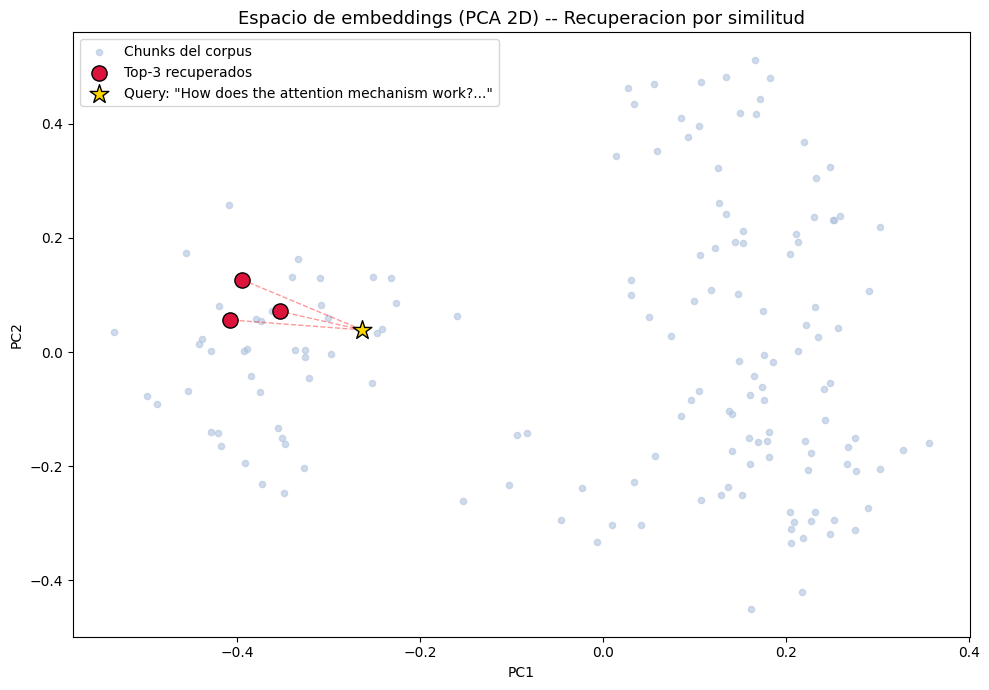


Varianza explicada por PCA: 17.6%


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Proyectar embeddings a 2D
pca = PCA(n_components=2)
chunks_2d = pca.fit_transform(chunk_embeddings)

# Elegir una consulta y encontrar sus chunks recuperados
query = "How does the attention mechanism work?"
query_vec = embed_model.encode([query], convert_to_numpy=True)
faiss.normalize_L2(query_vec)
scores, indices = index.search(query_vec, 3)
query_2d = pca.transform(query_vec)

# Graficar
fig, ax = plt.subplots(figsize=(10, 7))

# Todos los chunks
ax.scatter(chunks_2d[:, 0], chunks_2d[:, 1],
           c='lightsteelblue', s=20, alpha=0.6, label='Chunks del corpus')

# Chunks recuperados (top-3)
retrieved_2d = chunks_2d[indices[0]]
ax.scatter(retrieved_2d[:, 0], retrieved_2d[:, 1],
           c='crimson', s=120, edgecolors='black', zorder=5,
           label='Top-3 recuperados')

# Query
ax.scatter(query_2d[0, 0], query_2d[0, 1],
           c='gold', s=200, marker='*', edgecolors='black', zorder=6,
           label=f'Query: "{query[:40]}..."')

# Lineas de conexion query -> retrieved
for pt in retrieved_2d:
    ax.plot([query_2d[0, 0], pt[0]], [query_2d[0, 1], pt[1]],
            'r--', alpha=0.4, linewidth=1)

ax.set_title("Espacio de embeddings (PCA 2D) -- Recuperacion por similitud", fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada por PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")

<div align='justify'>

### Paso 9 — Experimentación: efecto de los hiperparámetros

Exploramos cómo cambian los resultados al modificar dos parámetros clave del pipeline:
- **`chunk_size`**: tamaño de los fragmentos (en palabras)
- **`top_k`**: número de chunks recuperados

</div>

In [ ]:
# Experimento: variar top_k
query = "What is backpropagation?"

print(f'Query: "{query}"\n')
print("Efecto de variar top_k (cantidad de chunks recuperados):")
print("-" * 70)

for k in [1, 3, 5]:
    answer, sources = rag_answer(query, top_k=k)
    print(f"\ntop_k = {k}:")
    print(f"  Respuesta: {answer}")
    scores_str = ", ".join([f"{s:.4f}" for _, s in sources])
    print(f"  Scores de similitud: [{scores_str}]")

Query: "What is backpropagation?"

Efecto de variar top_k (cantidad de chunks recuperados):
----------------------------------------------------------------------

top_k = 1:
  Respuesta: Backpropagation is an efficient application of the chain rule derived by Gottfried Wilhelm Leibniz in 1673 to networks of differentiable nodes.
  Scores de similitud: [0.6571]

top_k = 3:
  Respuesta: Backpropagation is an efficient application of the chain rule derived by Gottfried Wilhelm Leibniz in 1673 to networks of differentiable nodes.
  Scores de similitud: [0.6571, 0.6317, 0.5270]

top_k = 5:
  Respuesta: Backpropagation is an efficient application of the chain rule derived by Gottfried Wilhelm Leibniz in 1673 to networks of differentiable nodes.
  Scores de similitud: [0.6571, 0.6317, 0.5270, 0.4954, 0.4846]


In [ ]:
# Experimento: variar chunk_size y reconstruir el indice
query = "What types of layers are used in CNNs?"

print(f'Query: "{query}"\n')
print("Efecto de variar chunk_size (tamano de fragmento en palabras):")
print("=" * 70)

for cs in [100, 200, 300, 500]:
    # Re-segmentar
    exp_chunks = chunk_text(full_corpus, chunk_size=cs, overlap=30)

    # Re-indexar
    exp_embeddings = embed_model.encode(exp_chunks, show_progress_bar=False, convert_to_numpy=True)
    faiss.normalize_L2(exp_embeddings)
    exp_index = faiss.IndexFlatIP(exp_embeddings.shape[1])
    exp_index.add(exp_embeddings)

    # Recuperar
    q_vec = embed_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_vec)
    exp_scores, exp_indices = exp_index.search(q_vec, 3)

    # Generar con limite de contexto
    context_parts = []
    tw = 0
    for idx in exp_indices[0]:
        w = exp_chunks[idx].split()
        remaining = 300 - tw
        if remaining <= 0:
            break
        if len(w) > remaining:
            context_parts.append(" ".join(w[:remaining]))
            break
        context_parts.append(exp_chunks[idx])
        tw += len(w)
    context = "\n\n".join(context_parts)
    prompt = f"Use the context below to write a detailed answer to the question. Write at least two complete sentences.\n\nContext:\n{context}\n\nQuestion: {query}\n\nDetailed answer:"
    answer = generate(prompt)

    print(f"\nchunk_size = {cs:>5} -> {len(exp_chunks):>4} chunks | "
          f"top score: {exp_scores[0][0]:.4f}")
    print(f"  Respuesta: {answer[:200]}")

Query: "What types of layers are used in CNNs?"

Efecto de variar chunk_size (tamano de fragmento en palabras):

chunk_size =   100 ->  371 chunks | top score: 0.7512
  Respuesta: Sentence 1: The convolutional layer. Sent sentence 2: Single layer and unlayered networks are also used.

chunk_size =   200 ->  155 chunks | top score: 0.6463
  Respuesta: Sentence 1: The convolutional layer. Sent sentence 2: A few distinct types of layers are commonly

chunk_size =   300 ->   97 chunks | top score: 0.6542
  Respuesta: Sentence 1: Convolutional networks may include local and/or global pooling layers along with traditional convolutional layers. SentENCE 2: Pooling layers reduce the dimensions of data by combining the

chunk_size =   500 ->   57 chunks | top score: 0.6342
  Respuesta: Sentence 1: A few distinct types of layers are commonly used. These are further discussed below. SentENCE 2: The convolutional layer


<div align='justify'>

## DenseNet (Dense Convolutional Networks)

### Contexto y Motivación

Las redes convolucionales profundas enfrentan el problema del **vanishing gradient**: durante el backpropagation, los gradientes se multiplican por matrices de pesos en cada capa y, si estos valores son pequeños, el producto tiende a cero en las capas iniciales, que dejan de aprender:

$$\frac{\partial \mathcal{L}}{\partial x_0} = \frac{\partial \mathcal{L}}{\partial x_L} \cdot \prod_{i=1}^{L} \frac{\partial x_i}{\partial x_{i-1}} \;\xrightarrow{L \to \infty}\; 0$$

donde $\mathcal{L}$ es la función de pérdida y $x_0$ la salida de una capa inicial.

---

### Estándar vs ResNet vs DenseNet

Tanto ResNet como DenseNet atacan el vanishing gradient acortando el camino entre capas, pero con estrategias distintas. ResNet *suma* (puede sobrescribir información), DenseNet *concatena* (preserva toda la información original).

</div>

| Arquitectura | Operación | Fórmula |
|-------------|-----------|---------|
| Estándar    | Solo capa anterior | $$x_l = H_l(x_{l-1})$$ |
| ResNet      | **Suma** (skip connection) | $$x_l = H_l(x_{l-1}) + x_{l-1}$$ |
| **DenseNet** | **Concatena todas** las anteriores | $$x_l = H_l([x_0, x_1, \ldots, x_{l-1}])$$ |

Visualmente se puede ver:

<div align='center'>
<img src='https://miro.medium.com/v2/resize:fit:1100/format:webp/0*7H9mNwLLWFiLYhLb.jpeg' width=500px>
<br><em>Arriba: red estándar — Centro: ResNet — Abajo: DenseNet</em>
</div>

<div align='justify'>

</div>

<div align='justify'>

### Arquitectura de DenseNet

Tres componentes clave: **Dense Block**, **Bottleneck** y **Transition Layer**.

#### 1. Dense Block y Growth Rate ($k$)

Cada capa $H_l$ (BN → ReLU → Conv 3×3) recibe la concatenación de todos los feature maps anteriores. El *growth rate* $k$ controla cuántos canales nuevos agrega cada capa:

$$x_l = H_l([x_0, x_1, \ldots, x_{l-1}]), \qquad \text{canales}(l) = k_0 + k \cdot (l-1)$$

</div>

<div align='center'>
<table style="border-collapse:collapse; font-size:0.92em; margin:10px auto;">
<thead><tr style="background:#2166AC; color:white;">
  <th style="padding:7px 18px;">Capa</th>
  <th style="padding:7px 18px;">Canales entrada</th>
  <th style="padding:7px 18px;">Canales salida</th>
</tr></thead>
<tbody>
<tr><td align="center" style="padding:5px 18px;">l = 1</td><td align="center">k₀</td><td align="center">k₀ + k</td></tr>
<tr><td align="center" style="padding:5px 18px;">l = 2</td><td align="center">k₀ + k</td><td align="center">k₀ + 2k</td></tr>
<tr><td align="center" style="padding:5px 18px;">l = 3</td><td align="center">k₀ + 2k</td><td align="center">k₀ + 3k</td></tr>
<tr><td align="center" style="padding:5px 18px;">l = L</td><td align="center">k₀ + (L−1)k</td><td align="center">k₀ + Lk</td></tr>
</tbody>
</table>
<em>Valores típicos: k ∈ {12, 24, 32}</em>
</div>

<div align='justify'>

#### 2. Bottleneck — DenseNet-B

Una Conv 1×1 previa comprime los canales de entrada a $4k$ antes de la Conv 3×3, reduciendo la complejidad de $\mathcal{O}(k_0 + lk)$ a $\mathcal{O}(4k)$:

$$H_l:\; \underbrace{\text{BN} \to \text{ReLU} \to \text{Conv }1{\times}1}_{4k \text{ canales}} \;\to\; \underbrace{\text{BN} \to \text{ReLU} \to \text{Conv }3{\times}3}_{\text{extrae features}}$$

#### 3. Transition Layer

Entre bloques: **BN → Conv 1×1 → AvgPool 2×2**. Con compresión $\theta = 0.5$ reduce los canales a la mitad. La variante **DenseNet-BC** combina bottleneck y compresión.

</div>

<div align='center'>
<table style="border-collapse:collapse; font-size:0.92em; margin:10px auto;">
<thead><tr style="background:#2166AC; color:white;">
  <th style="padding:7px 18px;">Variante</th>
  <th style="padding:7px 18px;">Bottleneck</th>
  <th style="padding:7px 18px;">Compresión θ</th>
</tr></thead>
<tbody>
<tr><td align="center" style="padding:5px 18px;">DenseNet</td><td align="center">✗</td><td align="center">✗</td></tr>
<tr><td align="center" style="padding:5px 18px;">DenseNet-B</td><td align="center">✓</td><td align="center">✗</td></tr>
<tr><td align="center" style="padding:5px 18px;">DenseNet-C</td><td align="center">✗</td><td align="center">✓</td></tr>
<tr><td align="center" style="padding:5px 18px;"><b>DenseNet-BC</b></td><td align="center"><b>✓</b></td><td align="center"><b>✓</b></td></tr>
</tbody>
</table>
</div>

<div align='justify'>

#### 4. Variantes estándar (ImageNet, DenseNet-BC, θ = 0.5)

</div>

<div align='center'>
<table style="border-collapse:collapse; font-size:0.92em; margin:10px auto;">
<thead><tr style="background:#2166AC; color:white;">
  <th style="padding:7px 14px;">Modelo</th>
  <th style="padding:7px 14px;">Capas</th>
  <th style="padding:7px 14px;">Bloques</th>
  <th style="padding:7px 14px;">k</th>
  <th style="padding:7px 14px;">Params</th>
</tr></thead>
<tbody>
<tr><td align="center" style="padding:5px 14px;">DenseNet-121</td><td align="center">121</td><td align="center">[6, 12, 24, 16]</td><td align="center">32</td><td align="center">~8M</td></tr>
<tr><td align="center" style="padding:5px 14px;">DenseNet-169</td><td align="center">169</td><td align="center">[6, 12, 32, 32]</td><td align="center">32</td><td align="center">~14M</td></tr>
<tr><td align="center" style="padding:5px 14px;">DenseNet-201</td><td align="center">201</td><td align="center">[6, 12, 48, 32]</td><td align="center">32</td><td align="center">~20M</td></tr>
<tr><td align="center" style="padding:5px 14px;">DenseNet-264</td><td align="center">264</td><td align="center">[6, 12, 64, 48]</td><td align="center">32</td><td align="center">~34M</td></tr>
</tbody>
</table>
</div>

<div align='justify'>

### Ventajas frente a otras arquitecturas

</div>

<div align='center'>
<table style="border-collapse:collapse; font-size:0.92em; margin:10px auto;">
<thead><tr style="background:#2166AC; color:white;">
  <th style="padding:7px 18px;">Modelo</th>
  <th style="padding:7px 18px;">Top-1 Error (ImageNet)</th>
  <th style="padding:7px 18px;">Parámetros</th>
</tr></thead>
<tbody>
<tr><td align="center" style="padding:5px 18px;">ResNet-101</td><td align="center">23.6%</td><td align="center">~44M</td></tr>
<tr><td align="center" style="padding:5px 18px;">ResNet-152</td><td align="center">23.0%</td><td align="center">~60M</td></tr>
<tr><td align="center" style="padding:5px 18px;"><b>DenseNet-201</b></td><td align="center"><b>22.6% ↓</b></td><td align="center"><b>~20M ✓</b></td></tr>
<tr><td align="center" style="padding:5px 18px;"><b>DenseNet-264</b></td><td align="center"><b>22.2% ↓</b></td><td align="center"><b>~34M ✓</b></td></tr>
</tbody>
</table>
</div>

<div align='justify'>

- **Eficiencia de parámetros**: supera a ResNet en accuracy con significativamente menos parámetros gracias al growth rate pequeño y la reutilización de features.
- **Gradiente directo**: caminos cortos desde cualquier capa hasta la loss → entrenamiento más estable y convergencia más rápida.
- **Reutilización de features**: cada capa accede simultáneamente a representaciones de todos los niveles (bordes, formas, semántica) sin necesidad de re-aprenderlos.
- **Regularización implícita**: los múltiples caminos actúan como un ensemble de sub-redes → reduce overfitting, especialmente con datasets pequeños.

</div>

<div align='justify'>

### Limitaciones

- **Memoria GPU** ($\mathcal{O}(L^2 k)$): la concatenación acumulativa puede saturar la VRAM en bloques profundos. *Solución parcial*: gradient checkpointing (Pleiss et al., 2017) reduce el consumo a $\mathcal{O}(Lk)$, recomputando activaciones en el backward pass.
- **Inferencia más lenta**: a pesar de tener menos parámetros, las concatenaciones limitan el paralelismo eficiente en GPU.
- **Escalabilidad**: costo cuadrático con $L$ — poco práctico en imágenes de alta resolución o bloques muy profundos.
- **Superado en benchmarks modernos**: EfficientNet, Vision Transformers y ConvNeXt ofrecen mejor rendimiento y mayor throughput en la mayoría de tareas actuales.

</div>

<div align='justify'>

### ResNet vs DenseNet

</div>

<div align='center'>
<table style="border-collapse:collapse; font-size:0.92em; margin:10px auto;">
<thead><tr style="background:#2166AC; color:white;">
  <th style="padding:7px 16px;">Aspecto</th>
  <th style="padding:7px 16px;">ResNet</th>
  <th style="padding:7px 16px;">DenseNet</th>
</tr></thead>
<tbody>
<tr><td style="padding:5px 16px;">Operación skip</td><td align="center">Suma (+)</td><td align="center">Concatenación [·]</td></tr>
<tr><td style="padding:5px 16px;">Preservación de features</td><td align="center">Parcial</td><td align="center"><b>Total</b></td></tr>
<tr><td style="padding:5px 16px;">Parámetros</td><td align="center">Moderados</td><td align="center"><b>Menos</b></td></tr>
<tr><td style="padding:5px 16px;">Memoria GPU</td><td align="center">Moderada</td><td align="center">Alta</td></tr>
<tr><td style="padding:5px 16px;">Velocidad de inferencia</td><td align="center"><b>Rápida</b></td><td align="center">Más lenta</td></tr>
<tr><td style="padding:5px 16px;">Vanishing gradient</td><td align="center">Mitigado</td><td align="center"><b>Muy mitigado</b></td></tr>
<tr><td style="padding:5px 16px;">Regularización</td><td align="center">Moderada</td><td align="center"><b>Alta (implícita)</b></td></tr>
</tbody>
</table>
</div>

<div align='justify'>

**Usar DenseNet** cuando el dataset es pequeño, se prioriza eficiencia de parámetros, o el dominio es imagen médica o segmentación semántica.

**Considerar alternativas** (ResNet, EfficientNet, ViT) cuando se requiere velocidad de inferencia, escalabilidad con grandes datasets, o la memoria GPU es el cuello de botella.

</div>

### Practica

# Ejemplo Práctico: Construcción de una arquitectura DenseNet

A diferencia de las redes tradicionales o ResNet, DenseNet basa su flujo de información en la concatenación de los mapas de características. En este ejemplo de código (utilizando el popular framework PyTorch), implementaremos los componentes clave explicados en la teoría:

1. **La capa densa (*DenseLayer*) con Bottleneck**: Aplicaremos la convolución 1x1 para limitar el número de canales a $4k$, seguido de la convolución 3x3 que extrae $k$ canales nuevos (*growth rate*).
2. **La concatenación explícita**: Se demostrará mediante código la operación fundamental de DenseNet: $x_l = H_l([x_0, x_1, \ldots, x_{l-1}])$.
3. **Capa de Transición (*Transition Layer*)**: Construiremos la capa encargada de hacer la compresión de los canales y reducir la resolución espacial entre bloques densos.

In [ ]:
import torch
import torch.nn as nn

# 1. Implementación de una Capa Densa individual (con Bottleneck)
class DenseLayer(nn.Module):
    def __init__(self, num_input_features, growth_rate, bn_size=4):
        super(DenseLayer, self).__init__()

        # Bottleneck (DenseNet-B): Reduce los canales de entrada a 4 * k (growth_rate)
        # para mejorar la eficiencia y reducir la complejidad computacional.
        self.bottleneck = nn.Sequential(
            nn.BatchNorm2d(num_input_features),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_input_features, bn_size * growth_rate, kernel_size=1, stride=1, bias=False)
        )

        # Convolución principal que extrae exactamente 'growth_rate' nuevos canales (k)
        self.conv = nn.Sequential(
            nn.BatchNorm2d(bn_size * growth_rate),
            nn.ReLU(inplace=True),
            nn.Conv2d(bn_size * growth_rate, growth_rate, kernel_size=3, stride=1, padding=1, bias=False)
        )

    def forward(self, *prev_features):
        # La concatenación: La clave de DenseNet
        # Une todos los feature maps anteriores en la dimensión de canales (dim=1)
        # Esto refleja la fórmula: x_l = H_l([x_0, x_1, ..., x_{l-1}])
        concatenated_features = torch.cat(prev_features, dim=1)

        # Pasar por el bottleneck y extraer nuevas características
        bottleneck_output = self.bottleneck(concatenated_features)
        new_features = self.conv(bottleneck_output)

        return new_features

# 2. Implementación de la Transition Layer
class TransitionLayer(nn.Module):
    def __init__(self, num_input_features, num_output_features):
        super(TransitionLayer, self).__init__()

        # La capa de transición combina el factor de compresión (theta) mediante
        # una conv 1x1 y un Average Pooling 2x2 para reducir la dimensión espacial.
        self.transition = nn.Sequential(
            nn.BatchNorm2d(num_input_features),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_input_features, num_output_features, kernel_size=1, stride=1, bias=False),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.transition(x)


# ----------------------------------------------------
# Prueba de la capa para visualizar el flujo de datos
# ----------------------------------------------------
print("\\n--- DEMOSTRACIÓN DE DENSENET ---\\n")

k = 32 # Definimos nuestro Growth rate
canales_iniciales = 64

# Creamos una capa densa que recibe 64 canales y extrae 32 canales nuevos
capa_densa = DenseLayer(num_input_features=canales_iniciales, growth_rate=k)

# Simulamos la entrada de una imagen a la capa (Batch Size=1, Canales=64, Alto=56, Ancho=56)
x_0 = torch.randn(1, canales_iniciales, 56, 56)

# Obtenemos las nuevas características pasando x_0 por nuestra capa
nuevas_caracteristicas = capa_densa(x_0)

print(f"Dimensiones de entrada original (x_0): {x_0.shape}")
print(f"Nuevas características extraídas: {nuevas_caracteristicas.shape}")

# Concatenamos para la siguiente capa (generando nuestro x_1)
x_1 = torch.cat([x_0, nuevas_caracteristicas], dim=1)
print(f"Dimensiones de entrada preparadas para la siguiente capa (x_1): {x_1.shape}")
print("¡Nota cómo ahora tenemos los 64 canales previos + los 32 canales nuevos!")

\n--- DEMOSTRACIÓN DE DENSENET ---\n
Dimensiones de entrada original (x_0): torch.Size([1, 64, 56, 56])
Nuevas características extraídas: torch.Size([1, 32, 56, 56])
Dimensiones de entrada preparadas para la siguiente capa (x_1): torch.Size([1, 96, 56, 56])
¡Nota cómo ahora tenemos los 64 canales previos + los 32 canales nuevos!


### ¿Qué nos dice este ejemplo sobre la teoría analizada?

* **Growth Rate ($k$)**: Noten que la salida `nuevas_caracteristicas` tiene una dimensión de canales exacta de 32, el cual fue nuestro $k$ asignado. La red extrae exactamente $k$ nuevos mapas de características para ir incorporándolos paulatinamente al conocimiento de la red.
* **Operación de concatenación vs Suma (ResNet vs DenseNet)**: Al final del código de prueba, preparamos el *input* para una eventual próxima capa realizando explícitamente una concatenación en la función `torch.cat([x_0, nuevas_caracteristicas], dim=1)`. Este tensor resultante ahora tiene $64 + 32 = 96$ canales. Aquí vemos claramente la diferencia clave: una red ResNet hubiese *sumado* las activaciones manteniendo una salida de 64 canales perdiendo información original, mientras que DenseNet acumula el flujo.
* **El Bottleneck y la Complejidad Computacional**: Aunque el número de canales crece progresivamente tras cada capa (96, 128, 160...), el uso del *Bottleneck* (*Conv* de $1 \times 1$) dentro del objeto `DenseLayer` reduce temporalmente las operaciones a un límite fijo de $4k$ canales (en este ejemplo $4 \times 32 = 128$ canales de procesamiento intermedio) previniendo el crecimiento drástico de $\\mathcal{O}(L^2 k)$ en la RAM.

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import urllib.request

# 1. Cargar el modelo DenseNet-121 preentrenado (Forma actualizada)
print("Cargando modelo DenseNet-121...")
# Usamos weights=DEFAULT para obtener los mejores pesos disponibles en ImageNet
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
model.eval()

print("\n--- Estructura de las características (features) del modelo ---")
for name, child in model.features.named_children():
    print(f"- {name}: {child.__class__.__name__}")

# 3. Preparar una imagen de prueba (Corregido el error 403)
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg"
filename = "cat.jpg"

# Añadimos un User-Agent para simular la petición desde un navegador
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as response, open(filename, 'wb') as out_file:
    out_file.write(response.read())

img = Image.open(filename)

# 4. Transformaciones necesarias para ImageNet
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

img_t = transform(img).unsqueeze(0)

# 5. Realizar la predicción
print("\n--- Realizando inferencia ---")
with torch.no_grad():
    output = model(img_t)

# 6. Obtener las clases predichas
url_labels = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels_filename = "imagenet_classes.txt"

# Para este archivo txt normalmente GitHub no bloquea, pero le ponemos el header por seguridad
req_labels = urllib.request.Request(url_labels, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req_labels) as response, open(labels_filename, 'wb') as out_file:
    out_file.write(response.read())

with open(labels_filename, "r") as f:
    categories = [s.strip() for s in f.readlines()]

# Obtener el top 3 de predicciones
probabilities = torch.nn.functional.softmax(output[0], dim=0)
top3_prob, top3_catid = torch.topk(probabilities, 3)

for i in range(top3_prob.size(0)):
    print(f"Predicción {i+1}: {categories[top3_catid[i]]} (Probabilidad: {top3_prob[i].item()*100:.2f}%)")

Cargando modelo DenseNet-121...

--- Estructura de las características (features) del modelo ---
- conv0: Conv2d
- norm0: BatchNorm2d
- relu0: ReLU
- pool0: MaxPool2d
- denseblock1: _DenseBlock
- transition1: _Transition
- denseblock2: _DenseBlock
- transition2: _Transition
- denseblock3: _DenseBlock
- transition3: _Transition
- denseblock4: _DenseBlock
- norm5: BatchNorm2d

--- Realizando inferencia ---
Predicción 1: Egyptian cat (Probabilidad: 44.52%)
Predicción 2: tiger cat (Probabilidad: 30.82%)
Predicción 3: tabby (Probabilidad: 6.19%)


### Desempeño de la práctica

Para consolidar lo aprendido en ambos ejemplos prácticos, es fundamental entender cómo estas piezas de código individuales se traducen en el desempeño que observamos al hacer la inferencia con la red completa:

* **El rol de la Transition Layer y la Compresión ($\theta$)**: Si bien el *Bottleneck* controla el crecimiento de canales *dentro* de un bloque, la `TransitionLayer` que implementamos es vital para controlar el flujo de datos *entre* bloques densos. A través de la convolución de $1 \times 1$, esta capa aplica un factor de compresión (típicamente de **0.5** en la variante DenseNet-BC) para reducir el exceso de canales acumulados, mientras que el *Average Pooling* de $2 \times 2$ reduce la resolución espacial a la mitad. Esto evita que el costo computacional se vuelva inmanejable.
* **Correspondencia Directa con PyTorch**: Las clases `DenseLayer` y `TransitionLayer` que acabamos de definir desde cero son la representación exacta de los módulos internos `_DenseBlock` y `_Transition` que observamos al inspeccionar la arquitectura de `models.densenet121` en nuestro primer ejemplo. La red de Torchvision simplemente encadena múltiples instancias de estas clases.
* **El porqué de la precisión**: Al preservar el flujo de información intacto mediante la concatenación, DenseNet permite que la capa final de clasificación tenga acceso directo tanto a las características más complejas (detectadas al final de la red) como a las características de más bajo nivel (como las texturas del pelaje o los bordes, detectadas en la `conv0`). Esta riqueza de información es precisamente lo que le permitió a nuestro modelo DenseNet-121 preentrenado clasificar la imagen del gato atigrado con un nivel de confianza tan alto y detallado.


## Referencias

* Huang, G. et al. — "Densely Connected Convolutional Networks" — CVPR 2017

* A. Vaswani, N. Shazeer, N. Parmar, J. Uszkoreit, L. Jones, A. N. Gomez, L. Kaiser, and I. Polosukhin, "Attention is all you need", 2017.

* “Question Answering”, Huggingface. [En línea]. Disponible en: https://huggingface.co/tasks/question-answering.

* “google-bert/bert-base-uncased", Huggingface. [En línea]. Disponible en: https://huggingface.co/google-bert/bert-base-uncased.

* “What are transformers in artificial intelligence?”, AWS. [En línea]. Disponible en: https://aws.amazon.com/what-is/transformers-in-artificial-intelligence/.

* J. Devlin, M. W. Chang, K. Lee, y K. Toutanova, “BERT: Pre-training of deep bidirectional Transformers for language understanding”, 2019.

* Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., Goyal, N., Küttler, H., Lewis, M., Yih, W., Rocktäschel, T., Riedel, S., & Kiela, D. (2020). Retrieval-augmented generation for knowledge-intensive NLP tasks. Advances in Neural Information Processing Systems, 33, 9459–9474. https://arxiv.org/abs/2005.11401

* Turtlecrown. (2023). RAG diagram [Ilustración]. Wikimedia Commons. https://commons.wikimedia.org/wiki/File:RAG_diagram.svg